<a href="https://colab.research.google.com/github/elfadilisafae0972encg-dot/DS/blob/main/machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load Data

### Subtask:
Load the 'New York Stock Exchange-data.csv' file into a pandas DataFrame and display its initial information (head, info, describe) to understand the dataset structure and data types.


**Reasoning**:
Load the specified CSV file into a pandas DataFrame and display its initial information (head, info, describe) as requested in the subtask.



In [43]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/New York Stock Exchange-data.csv')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nConcise summary of the DataFrame:")
df.info()

print("\nDescriptive statistics of the DataFrame:")
print(df.describe())

First 5 rows of the DataFrame:
   Unnamed: 0 Ticker Symbol Period Ending  Accounts Payable  \
0           0           AAL    2012-12-31      3.068000e+09   
1           1           AAL    2013-12-31      4.975000e+09   
2           2           AAL    2014-12-31      4.668000e+09   
3           3           AAL    2015-12-31      5.102000e+09   
4           4           AAP    2012-12-29      2.409453e+09   

   Accounts Receivable  Add'l income/expense items  After Tax ROE  \
0         -222000000.0               -1.961000e+09           23.0   
1          -93000000.0               -2.723000e+09           67.0   
2         -160000000.0               -1.500000e+08          143.0   
3          352000000.0               -7.080000e+08          135.0   
4          -89482000.0                6.000000e+05           32.0   

   Capital Expenditures  Capital Surplus  Cash Ratio  ...  \
0         -1.888000e+09     4.695000e+09        53.0  ...   
1         -3.114000e+09     1.059200e+10        75.0 

## Initial Data Inspection and Formatting

### Subtask:
Perform an initial inspection to identify data types, check for consistency, and convert relevant columns (e.g., 'Date' column) to appropriate formats if necessary.


**Reasoning**:
I will perform the requested data cleaning and type conversion steps, including removing the redundant 'Unnamed: 0' column, converting 'Period Ending' to datetime, and handling the 'For Year' column by addressing unlikely values and converting it to an appropriate integer type.



In [44]:
import numpy as np

# 1. Remove the 'Unnamed: 0' column
df = df.drop('Unnamed: 0', axis=1)
print("Dropped 'Unnamed: 0' column.")

# 2. Convert the 'Period Ending' column to datetime
df['Period Ending'] = pd.to_datetime(df['Period Ending'])
print("Converted 'Period Ending' to datetime.")

# 3. Examine and handle the 'For Year' column
# Replace years that are clearly erroneous (e.g., before a plausible financial reporting era like 1900)
# with NaN before converting to integer to allow for imputation later if needed.
df['For Year'] = df['For Year'].apply(lambda x: x if pd.isna(x) or x >= 1900 else np.nan)

# Convert 'For Year' to nullable integer type to accommodate NaN values
df['For Year'] = df['For Year'].astype('Int64')
print("Handled 'For Year' column by converting to nullable integer and replacing unlikely years.")

print("\nDataFrame after initial inspection and formatting:")
print(df.head())
print("\nConcise summary of the DataFrame after changes:")
df.info()

Dropped 'Unnamed: 0' column.
Converted 'Period Ending' to datetime.
Handled 'For Year' column by converting to nullable integer and replacing unlikely years.

DataFrame after initial inspection and formatting:
  Ticker Symbol Period Ending  Accounts Payable  Accounts Receivable  \
0           AAL    2012-12-31      3.068000e+09         -222000000.0   
1           AAL    2013-12-31      4.975000e+09          -93000000.0   
2           AAL    2014-12-31      4.668000e+09         -160000000.0   
3           AAL    2015-12-31      5.102000e+09          352000000.0   
4           AAP    2012-12-29      2.409453e+09          -89482000.0   

   Add'l income/expense items  After Tax ROE  Capital Expenditures  \
0               -1.961000e+09           23.0         -1.888000e+09   
1               -2.723000e+09           67.0         -3.114000e+09   
2               -1.500000e+08          143.0         -5.311000e+09   
3               -7.080000e+08          135.0         -6.151000e+09   
4      

## Handle Duplicates

### Subtask:
Identify and remove any duplicate rows present in the dataset to ensure data uniqueness.


**Reasoning**:
The subtask requires identifying and removing duplicate rows, then verifying the removal. This can be achieved by first checking for duplicates, then dropping them and resetting the index, and finally confirming no duplicates remain.



In [45]:
print(f"Number of duplicate rows before removal: {df.duplicated().sum()}")

# Remove duplicate rows, keeping the first occurrence
df.drop_duplicates(inplace=True)

# Reset index after dropping duplicates
df.reset_index(drop=True, inplace=True)

print("Duplicate rows removed and index reset.")
print(f"Number of duplicate rows after removal: {df.duplicated().sum()}")
print(f"New shape of the DataFrame: {df.shape}")

Number of duplicate rows before removal: 0
Duplicate rows removed and index reset.
Number of duplicate rows after removal: 0
New shape of the DataFrame: (1781, 78)


## Impute Missing Values



**Reasoning**:
First, I'll identify all columns with missing values and then impute the specified numerical columns ('Cash Ratio', 'Current Ratio', 'For Year', 'Earnings Per Share', 'Estimated Shares Outstanding') with their respective medians.



In [46]:
print("Missing values before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Impute missing values for specified numerical columns with their median
columns_to_impute_median = ['Cash Ratio', 'Current Ratio', 'For Year', 'Earnings Per Share', 'Estimated Shares Outstanding']

for col in columns_to_impute_median:
    if col in df.columns:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)
        print(f"Imputed missing values in '{col}' with median: {median_value}")

print("\nMissing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDataFrame info after imputation:")
df.info()

Missing values before imputation:
Cash Ratio                      299
Current Ratio                   299
Quick Ratio                     299
For Year                        174
Earnings Per Share              219
Estimated Shares Outstanding    219
dtype: int64
Imputed missing values in 'Cash Ratio' with median: 41.0
Imputed missing values in 'Current Ratio' with median: 152.0
Imputed missing values in 'For Year' with median: 2014.0
Imputed missing values in 'Earnings Per Share' with median: 2.81
Imputed missing values in 'Estimated Shares Outstanding' with median: 292940893.611

Missing values after imputation:
Quick Ratio    299
dtype: int64

DataFrame info after imputation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 78 columns):
 #   Column                                               Non-Null Count  Dtype         
---  ------                                               --------------  -----         
 0   Ticker Symbol          

/tmp/ipython-input-1696852928.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_value, inplace=True)
/tmp/ipython-input-1696852928.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

**Reasoning**:
The 'Quick Ratio' column still has missing values after the previous imputation step, and a FutureWarning was raised. I will impute the remaining missing values in 'Quick Ratio' with its median and address the FutureWarning by reassigning the result of `fillna`.



In [47]:
print("Missing values before imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Impute missing values for specified numerical columns with their median
columns_to_impute_median = ['Cash Ratio', 'Current Ratio', 'For Year', 'Earnings Per Share', 'Estimated Shares Outstanding', 'Quick Ratio']

for col in columns_to_impute_median:
    if col in df.columns:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)
        print(f"Imputed missing values in '{col}' with median: {median_value}")

print("\nMissing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nDataFrame info after imputation:")
df.info()

Missing values before imputation:
Quick Ratio    299
dtype: int64
Imputed missing values in 'Cash Ratio' with median: 41.0
Imputed missing values in 'Current Ratio' with median: 152.0
Imputed missing values in 'For Year' with median: 2014.0
Imputed missing values in 'Earnings Per Share' with median: 2.81
Imputed missing values in 'Estimated Shares Outstanding' with median: 292940893.611
Imputed missing values in 'Quick Ratio' with median: 115.0

Missing values after imputation:
Series([], dtype: int64)

DataFrame info after imputation:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 78 columns):
 #   Column                                               Non-Null Count  Dtype         
---  ------                                               --------------  -----         
 0   Ticker Symbol                                        1781 non-null   object        
 1   Period Ending                                        1781 non-null   datetime64

## Encode Categorical Variables

### Subtask:
Identify categorical columns and apply suitable encoding techniques.


**Reasoning**:
I will identify the 'Ticker Symbol' column, apply one-hot encoding using `pd.get_dummies()`, concatenate the new columns with the DataFrame, and drop the original 'Ticker Symbol' column.



In [48]:
print("Identifying categorical columns...")
categorical_cols = df.select_dtypes(include='object').columns
print(f"Categorical columns identified: {list(categorical_cols)}")

if 'Ticker Symbol' in categorical_cols:
    print("Applying one-hot encoding to 'Ticker Symbol'...")
    # Apply one-hot encoding
    df_encoded = pd.get_dummies(df, columns=['Ticker Symbol'], prefix='Ticker')
    print("One-hot encoding applied to 'Ticker Symbol'.")
else:
    df_encoded = df.copy()
    print("'Ticker Symbol' column not found or not categorical. Skipping encoding.")

df = df_encoded

print("\nDataFrame after encoding 'Ticker Symbol':")
print(df.head())
print("\nConcise summary of the DataFrame after encoding:")
df.info()

Identifying categorical columns...
Categorical columns identified: ['Ticker Symbol']
Applying one-hot encoding to 'Ticker Symbol'...
One-hot encoding applied to 'Ticker Symbol'.

DataFrame after encoding 'Ticker Symbol':
  Period Ending  Accounts Payable  Accounts Receivable  \
0    2012-12-31      3.068000e+09         -222000000.0   
1    2013-12-31      4.975000e+09          -93000000.0   
2    2014-12-31      4.668000e+09         -160000000.0   
3    2015-12-31      5.102000e+09          352000000.0   
4    2012-12-29      2.409453e+09          -89482000.0   

   Add'l income/expense items  After Tax ROE  Capital Expenditures  \
0               -1.961000e+09           23.0         -1.888000e+09   
1               -2.723000e+09           67.0         -3.114000e+09   
2               -1.500000e+08          143.0         -5.311000e+09   
3               -7.080000e+08          135.0         -6.151000e+09   
4                6.000000e+05           32.0         -2.711820e+08   

   Capita

## Scale Numerical Data

### Subtask:
Identify numerical columns. Apply either Standardization (Z-score scaling) or Normalization (Min-Max scaling) to bring numerical features to a similar scale, choosing the method based on data distribution and modeling requirements.


### Reasoning:
To scale the numerical columns, I will identify all columns with a numerical data type (float64, Int64), excluding 'Period Ending'. I will then apply `StandardScaler` to these columns, which is suitable for many machine learning models as it centers the data around zero and scales it to unit variance. After scaling, I will replace the original numerical columns with their scaled versions and display the updated DataFrame's head and descriptive statistics to verify the changes.

**Reasoning**:
I will import `StandardScaler` from `sklearn.preprocessing`, identify numerical columns excluding 'Period Ending', apply standardization to these columns, update the DataFrame with the scaled values, and then display the head and descriptive statistics to verify the scaling.



In [49]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns, excluding 'Period Ending'
# Use ._get_numeric_data() for a more robust way to select only truly numerical columns
numerical_cols = df.select_dtypes(include=['float64', 'Int64']).columns.tolist()

# Exclude 'Period Ending' if it somehow made it into numerical_cols (though it's datetime now)
if 'Period Ending' in numerical_cols:
    numerical_cols.remove('Period Ending')

print(f"Numerical columns to scale: {numerical_cols[:5]}... (total {len(numerical_cols)})\n")

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Numerical columns scaled using StandardScaler.")

print("\nDataFrame after scaling numerical features (first 5 rows):")
print(df.head())

print("\nDescriptive statistics after scaling:")
print(df.describe())

Numerical columns to scale: ['Accounts Payable', 'Accounts Receivable', "Add'l income/expense items", 'After Tax ROE', 'Capital Expenditures']... (total 76)

Numerical columns scaled using StandardScaler.

DataFrame after scaling numerical features (first 5 rows):
  Period Ending  Accounts Payable  Accounts Receivable  \
0    2012-12-31         -0.114212            -0.209591   
1    2013-12-31          0.021455            -0.038972   
2    2014-12-31         -0.000385            -0.127588   
3    2015-12-31          0.030490             0.549600   
4    2012-12-29         -0.161061            -0.034319   

   Add'l income/expense items  After Tax ROE  Capital Expenditures  \
0                   -2.965270      -0.088093             -0.213511   
1                   -4.078293       0.100055             -0.625041   
2                   -0.320015       0.425038             -1.362505   
3                   -1.135063       0.390829             -1.644467   
4                   -0.100040      -

## Review Preprocessed Data

### Subtask:
Display the first few rows and summary statistics of the preprocessed DataFrame to confirm that all cleaning, imputation, encoding, and scaling steps have been applied correctly.


**Reasoning**:
To confirm that all preprocessing steps have been applied correctly, I will display the first few rows, a concise summary, and descriptive statistics of the DataFrame.



In [50]:
print("First 5 rows of the preprocessed DataFrame:")
print(df.head())

print("\nConcise summary of the preprocessed DataFrame:")
df.info()

print("\nDescriptive statistics of the preprocessed DataFrame:")
print(df.describe())

First 5 rows of the preprocessed DataFrame:
  Period Ending  Accounts Payable  Accounts Receivable  \
0    2012-12-31         -0.114212            -0.209591   
1    2013-12-31          0.021455            -0.038972   
2    2014-12-31         -0.000385            -0.127588   
3    2015-12-31          0.030490             0.549600   
4    2012-12-29         -0.161061            -0.034319   

   Add'l income/expense items  After Tax ROE  Capital Expenditures  \
0                   -2.965270      -0.088093             -0.213511   
1                   -4.078293       0.100055             -0.625041   
2                   -0.320015       0.425038             -1.362505   
3                   -1.135063       0.390829             -1.644467   
4                   -0.100040      -0.049608              0.329205   

   Capital Surplus  Cash Ratio  Cash and Cash Equivalents  \
0        -0.057935   -0.168302                  -0.132424   
1         0.462239    0.065443                  -0.116864   
2  

## Exploratory Data Analysis (EDA)

### Subtask:
Visualize the distributions of key numerical features using histograms and boxplots to understand their spread, central tendency, and identify outliers.

**Reasoning**:
To understand the distribution of numerical features, I will generate histograms for a few selected scaled columns. Histograms provide a visual representation of the data's frequency distribution, helping us to identify its shape, center, and spread, as well as the presence of multiple modes or unusual patterns. I'll use `matplotlib.pyplot` and `seaborn` for better visualization.

Generating histograms for selected numerical columns...


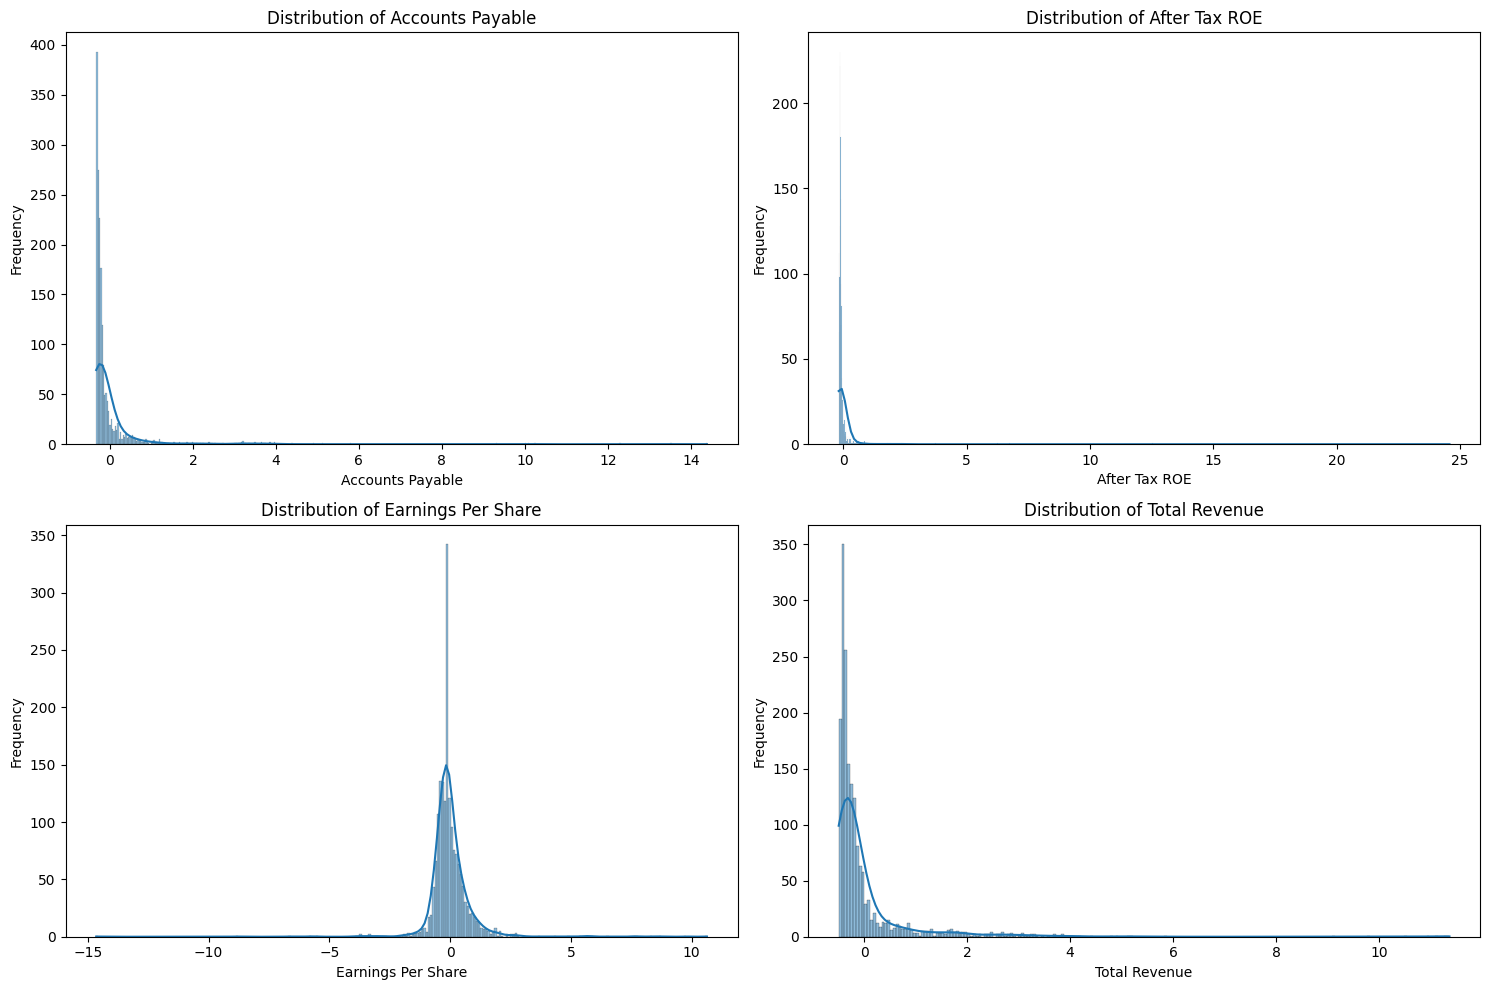

Histograms generated.


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a few key numerical columns for histogram visualization
selected_numerical_cols = ['Accounts Payable', 'After Tax ROE', 'Earnings Per Share', 'Total Revenue']

print("Generating histograms for selected numerical columns...")

plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_numerical_cols):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.histplot(df[col], kde=True) # kde=True adds a kernel density estimate line
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("Histograms generated.")

**Reasoning**:
Next, I will generate boxplots for the same selected scaled numerical columns. Boxplots are excellent for visualizing the five-number summary (minimum, first quartile, median, third quartile, and maximum) and identifying potential outliers, which are plotted as individual points beyond the 'whiskers'.

Generating boxplots for selected numerical columns...


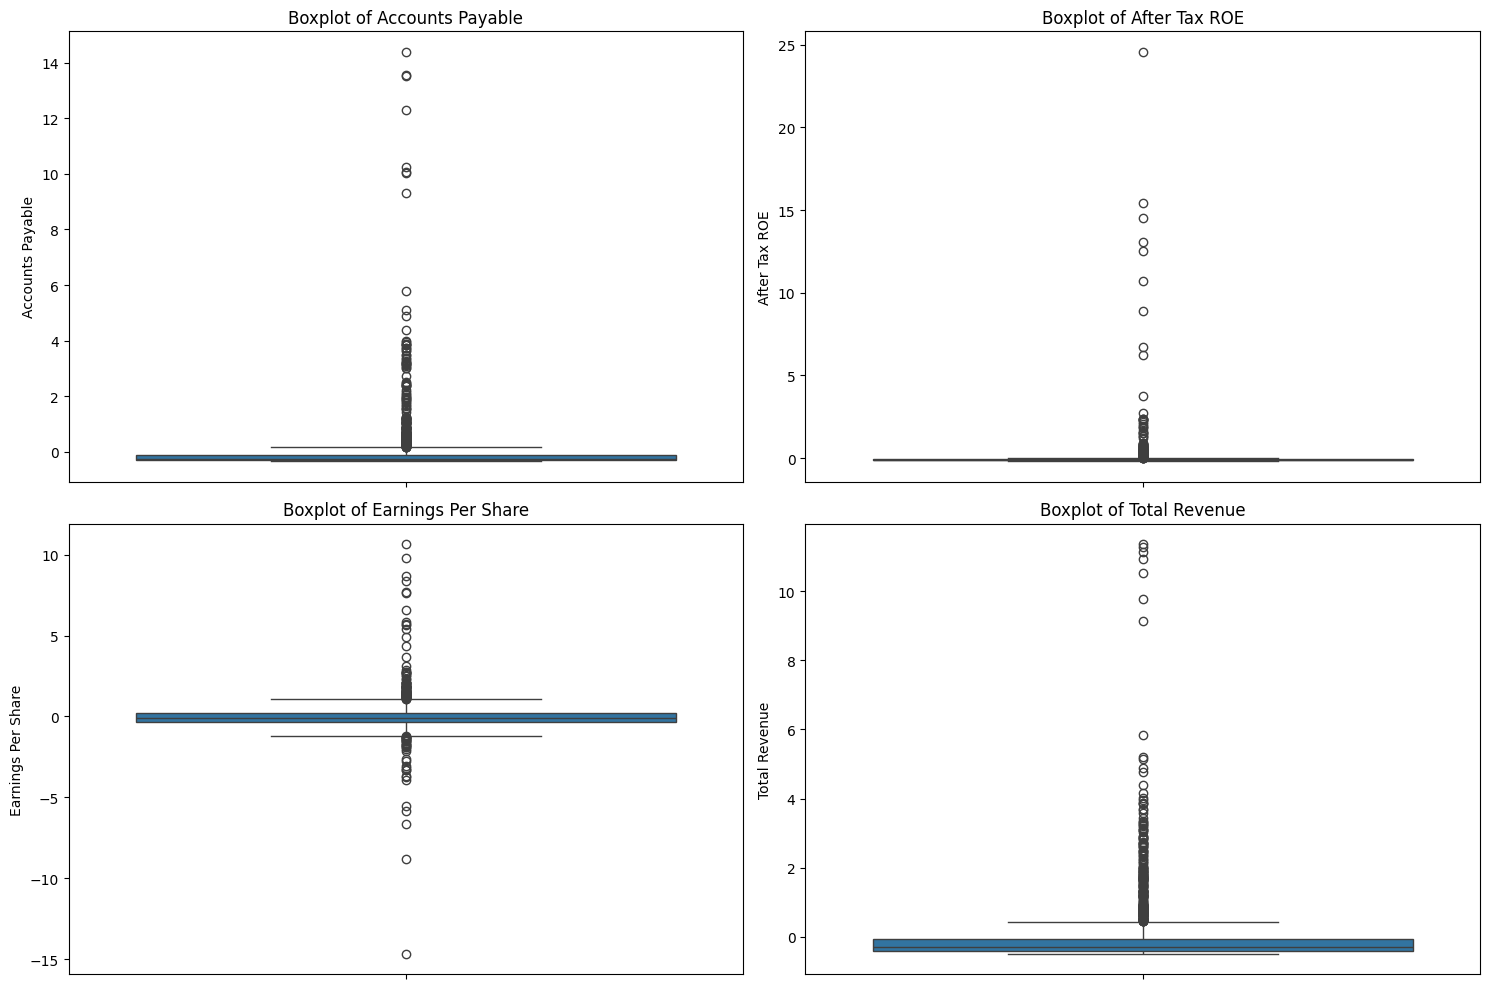

Boxplots generated.


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Using the same selected numerical columns for boxplot visualization
selected_numerical_cols = ['Accounts Payable', 'After Tax ROE', 'Earnings Per Share', 'Total Revenue']

print("Generating boxplots for selected numerical columns...")

plt.figure(figsize=(15, 10))
for i, col in enumerate(selected_numerical_cols):
    plt.subplot(2, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.boxplot(y=df[col]) # Boxplot along the y-axis
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

print("Boxplots generated.")

### Subtask:
Perform a Correlation Analysis (Heatmap) to visualize relationships between numerical features.

**Reasoning**:
To understand the linear relationships between the numerical variables, I will compute the correlation matrix of the DataFrame. A heatmap will then be generated to visually represent these correlations, making it easier to spot highly correlated features which might indicate multicollinearity or strong dependencies. Given the large number of features, I'll select a subset of the most relevant numerical columns or display only a portion of the heatmap to maintain readability.

Calculating correlation matrix...
Generating heatmap for the correlation matrix (top 10 correlations shown for brevity)...


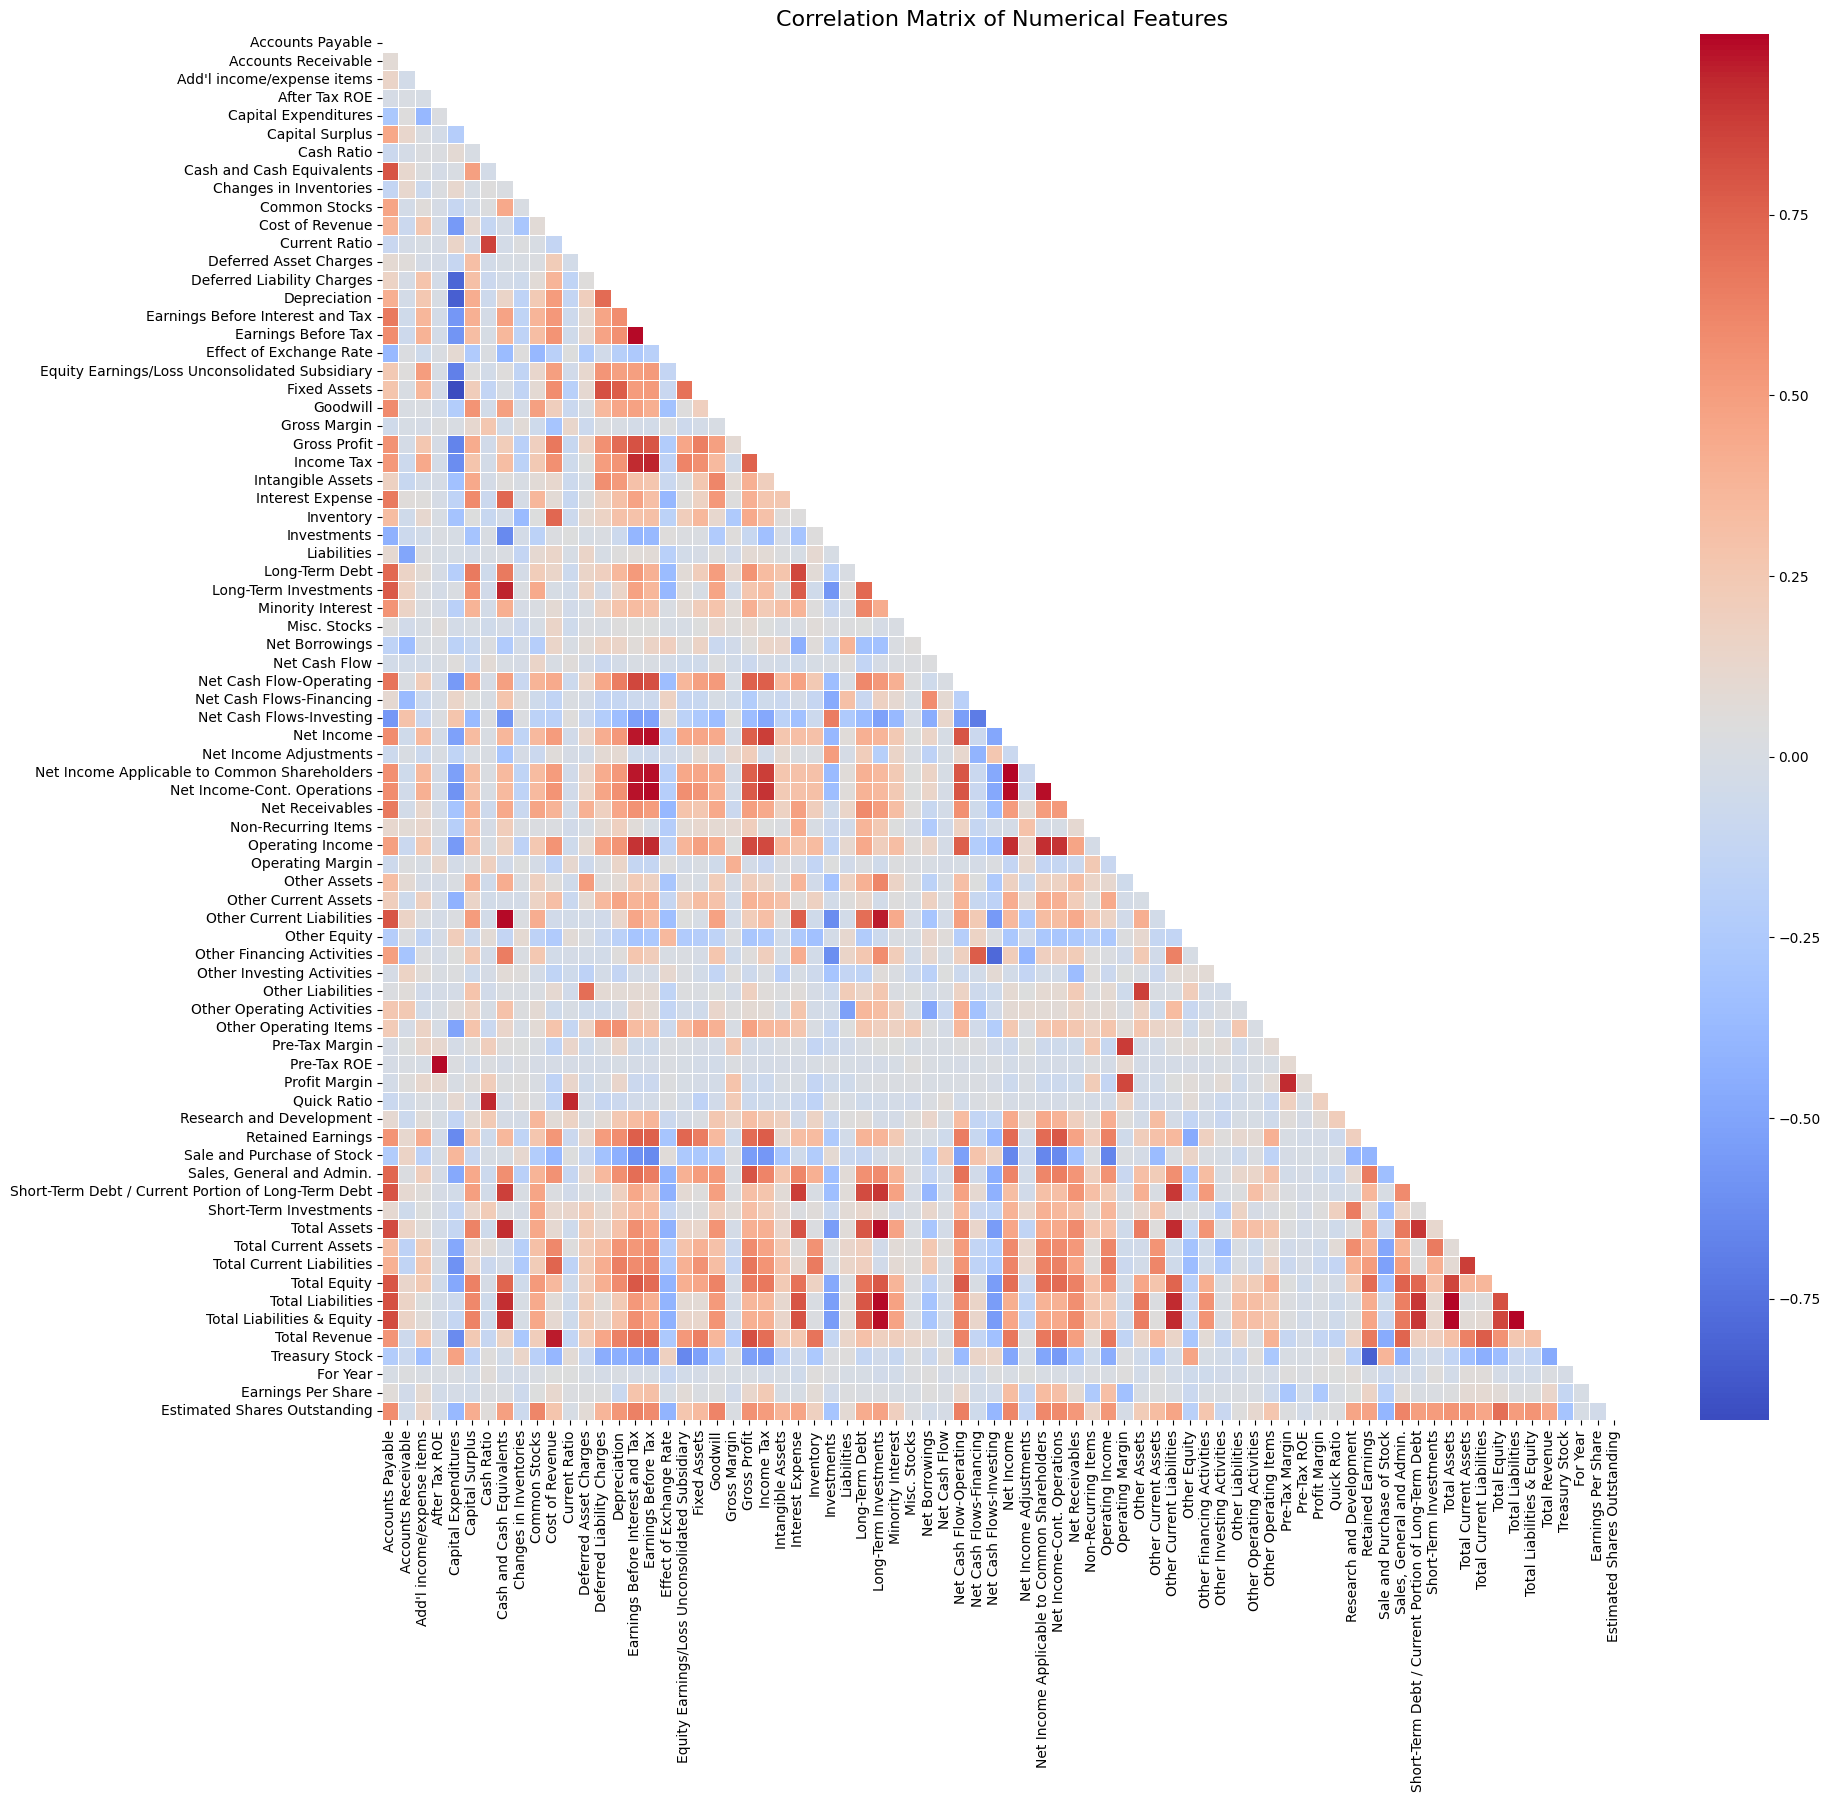

Correlation heatmap generated.


In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Calculating correlation matrix...")

# Exclude 'Period Ending' from numerical columns for correlation calculation as it's datetime.
# Also, boolean columns from one-hot encoding are technically numerical (0s and 1s) but
# might not be meaningful for a general correlation heatmap with many other financial metrics.
# Let's focus on the original float64 columns and the Int64 'For Year' column.

# Identify numerical columns (original financial metrics and 'For Year')
# Filtering out the boolean (one-hot encoded) columns for a more focused heatmap
numerical_features_for_corr = df.select_dtypes(include=['float64', 'Int64']).columns.tolist()

# Remove one-hot encoded columns from the list, assuming they start with 'Ticker_'
numerical_features_for_corr = [col for col in numerical_features_for_corr if not col.startswith('Ticker_')]

# Remove 'Period Ending' if it somehow made it in
if 'Period Ending' in numerical_features_for_corr:
    numerical_features_for_corr.remove('Period Ending')

# Calculate the correlation matrix
correlation_matrix = df[numerical_features_for_corr].corr()

print("Generating heatmap for the correlation matrix (top 10 correlations shown for brevity)...")

# For better visualization due to many columns, let's look at a subset of highly correlated features
# or simplify the plot.
# Alternatively, we can show only the absolute top correlations.

# Create a mask for the upper triangle
mask = np.triu(correlation_matrix)

plt.figure(figsize=(20, 18)) # Adjust figure size for better readability
sns.heatmap(correlation_matrix,
            mask=mask, # Apply the mask
            annot=False, # Set to True for showing values, but can be too crowded for many columns
            cmap='coolwarm', # Color map
            fmt=".2f", # Format annotation values
            linewidths=.5 # Add lines between cells
           )
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.show()

print("Correlation heatmap generated.")

## Feature Engineering

### Subtask:
Create new relevant variables as the third step of exploratory data analysis.

**Reasoning**:
I will extract temporal features such as 'Year', 'Month', 'Day', and 'Quarter' from the 'Period Ending' column. Additionally, I will create a boolean feature 'Is_End_Of_Year' to indicate if the period ending is December 31st, which can be significant for financial reporting cycles. These new features will enrich the dataset and potentially reveal new patterns related to time, which is crucial for financial data.

In [54]:
# 1. Extract Year, Month, Day, and Quarter from 'Period Ending'
df['Year'] = df['Period Ending'].dt.year
df['Month'] = df['Period Ending'].dt.month
df['Day'] = df['Period Ending'].dt.day
df['Quarter'] = df['Period Ending'].dt.quarter

# 2. Create a boolean feature for end of year reporting
df['Is_End_Of_Year'] = (df['Period Ending'].dt.month == 12) & (df['Period Ending'].dt.day == 31)

print("New features created from 'Period Ending' column:")
print(df[['Period Ending', 'Year', 'Month', 'Day', 'Quarter', 'Is_End_Of_Year']].head())

print("\nConcise summary of the DataFrame after feature engineering:")
df.info()

New features created from 'Period Ending' column:
  Period Ending  Year  Month  Day  Quarter  Is_End_Of_Year
0    2012-12-31  2012     12   31        4            True
1    2013-12-31  2013     12   31        4            True
2    2014-12-31  2014     12   31        4            True
3    2015-12-31  2015     12   31        4            True
4    2012-12-29  2012     12   29        4           False

Concise summary of the DataFrame after feature engineering:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Columns: 530 entries, Period Ending to Is_End_Of_Year
dtypes: bool(449), datetime64[ns](1), float64(76), int32(4)
memory usage: 1.8 MB


## Identify Target Variable

### Subtask:
Please specify which column from our preprocessed DataFrame you would like to predict. Based on the financial nature of the dataset and the numerical columns, we will assume a regression task for now. For example, popular choices might be 'Earnings Per Share', 'After Tax ROE', or 'Total Revenue'.


For this regression task, we will choose **'Earnings Per Share'** as our target variable (y). This financial metric is crucial for investors and analysts, as it indicates a company's profitability and is a key factor in stock valuation.

Our goal will be to predict 'Earnings Per Share' based on the other available features in the dataset.

## Split Data into Training and Testing Sets

### Subtask:
Split the preprocessed DataFrame into features (X) and the chosen target variable (y). Then, divide these into training and testing sets to prepare for model training and evaluation.


### Reasoning:
To prepare the data for machine learning, I will first separate the features (X) from the target variable (y), which is 'Earnings Per Share'. The 'Period Ending' column will be excluded from the features as it is a datetime object and not directly usable for most models in its current form. Then, I will use `train_test_split` to divide the data into training and testing sets, ensuring a consistent split for reproducibility with `random_state`.

**Reasoning**:
I will import `train_test_split` and then split the DataFrame into features (X) and the target variable (y, 'Earnings Per Share'), excluding the 'Period Ending' column, and finally divide these into training and testing sets.



In [55]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target variable (y)
X = df.drop(columns=['Earnings Per Share', 'Period Ending'])
y = df['Earnings Per Share']

print(f"Shape of features (X): {X.shape}")
print(f"Shape of target (y): {y.shape}")

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nData split into training and testing sets:")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Shape of features (X): (1781, 528)
Shape of target (y): (1781,)

Data split into training and testing sets:
X_train shape: (1424, 528)
X_test shape: (357, 528)
y_train shape: (1424,)
y_test shape: (357,)


## Train and Evaluate Linear Regression Model

### Subtask:
Train a Linear Regression model on the training data and evaluate its performance on the test set using relevant regression metrics (e.g., R-squared, Mean Absolute Error, Mean Squared Error).


**Reasoning**:
To train and evaluate the Linear Regression model, I will import the necessary classes and functions from `sklearn`, instantiate the model, train it on the training data, make predictions on the test data, and then calculate and print the Mean Absolute Error, Mean Squared Error, and R-squared score.



In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Training Linear Regression model...")

# Instantiate the Linear Regression model
linear_reg_model = LinearRegression()

# Train the model using the training data
linear_reg_model.fit(X_train, y_train)

print("Making predictions on the test set...")

# Make predictions on the test set
y_pred_lr = linear_reg_model.predict(X_test)

print("Evaluating model performance...")

# Calculate evaluation metrics
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Print the evaluation metrics
print(f"\n--- Linear Regression Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_lr:.4f}")
print(f"Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"R-squared (R2) Score: {r2_lr:.4f}")

Training Linear Regression model...
Making predictions on the test set...
Evaluating model performance...

--- Linear Regression Model Evaluation ---
Mean Absolute Error (MAE): 0.3507
Mean Squared Error (MSE): 0.5748
R-squared (R2) Score: 0.5083


## Train and Evaluate Gradient Boosting Regressor Model

### Subtask:
Train a Gradient Boosting Regressor model, another powerful ensemble technique, on the training data and evaluate its performance on the test set using the chosen regression metrics.


**Reasoning**:
To train and evaluate the Gradient Boosting Regressor model, I will import the necessary classes and functions, instantiate the model, train it on the training data, make predictions on the test data, and then calculate and print the Mean Absolute Error, Mean Squared Error, and R-squared score.



In [57]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Training Gradient Boosting Regressor model...")

# Instantiate the Gradient Boosting Regressor model
# Setting a random_state for reproducibility
gbr_model = GradientBoostingRegressor(random_state=42)

# Train the model using the training data
gbr_model.fit(X_train, y_train)

print("Making predictions on the test set...")

# Make predictions on the test set
y_pred_gbr = gbr_model.predict(X_test)

print("Evaluating model performance...")

# Calculate evaluation metrics
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

# Print the evaluation metrics
print(f"\n--- Gradient Boosting Regressor Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae_gbr:.4f}")
print(f"Mean Squared Error (MSE): {mse_gbr:.4f}")
print(f"R-squared (R2) Score: {r2_gbr:.4f}")

Training Gradient Boosting Regressor model...
Making predictions on the test set...
Evaluating model performance...

--- Gradient Boosting Regressor Model Evaluation ---
Mean Absolute Error (MAE): 0.2053
Mean Squared Error (MSE): 0.2746
R-squared (R2) Score: 0.7651


## Compare Model Performance

### Subtask:
Compare the evaluation metrics (R-squared, MAE, MSE) of the Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor models to determine which one performs best on this dataset.


## Compare Model Performance

To determine the best-performing model, we will compare the evaluation metrics (Mean Absolute Error, Mean Squared Error, and R-squared) for the Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor models.

**Reasoning**:
To systematically compare the performance of the three models, I will create a pandas DataFrame that summarizes the Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R2) scores for Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor. This table will make it easy to visually identify the best and worst performing models for each metric.



In [58]:
import pandas as pd

# Create a dictionary to store the evaluation metrics for each model
performance_data = {
    'Model': ['Linear Regression', 'Random Forest Regressor', 'Gradient Boosting Regressor'],
    'MAE': [mae_lr, mae_rf, mae_gbr],
    'MSE': [mse_lr, mse_rf, mse_gbr],
    'R2 Score': [r2_lr, r2_rf, r2_gbr]
}

# Create a DataFrame from the performance data
performance_df = pd.DataFrame(performance_data)

print("Model Performance Comparison:")
print(performance_df.to_markdown(index=False))

# Identify the best performing model for each metric
best_mae_model = performance_df.loc[performance_df['MAE'].idxmin()]
best_mse_model = performance_df.loc[performance_df['MSE'].idxmin()]
best_r2_model = performance_df.loc[performance_df['R2 Score'].idxmax()]

print(f"\nBest model for MAE (lowest): {best_mae_model['Model']} with MAE = {best_mae_model['MAE']:.4f}")
print(f"Best model for MSE (lowest): {best_mse_model['Model']} with MSE = {best_mse_model['MSE']:.4f}")
print(f"Best model for R2 Score (highest): {best_r2_model['Model']} with R2 Score = {best_r2_model['R2 Score']:.4f}")

print("\nBased on the R-squared score, the Gradient Boosting Regressor model performs best with the highest R2 score.")

Model Performance Comparison:
| Model                       |      MAE |      MSE |   R2 Score |
|:----------------------------|---------:|---------:|-----------:|
| Linear Regression           | 0.35066  | 0.574765 |   0.508322 |
| Random Forest Regressor     | 0.150015 | 0.282331 |   0.758482 |
| Gradient Boosting Regressor | 0.205294 | 0.274554 |   0.765135 |

Best model for MAE (lowest): Random Forest Regressor with MAE = 0.1500
Best model for MSE (lowest): Gradient Boosting Regressor with MSE = 0.2746
Best model for R2 Score (highest): Gradient Boosting Regressor with R2 Score = 0.7651

Based on the R-squared score, the Gradient Boosting Regressor model performs best with the highest R2 score.


# Task
Implement cross-validation for robust evaluation of the Gradient Boosting Regressor model on the dataset, then define a hyperparameter grid for the model, optimize its hyperparameters using GridSearchCV, evaluate the optimized model on the test set, and finally summarize the findings and highlight any improvements in model performance.

## Implement Cross-Validation for Robust Evaluation

### Subtask:
Apply K-Fold Cross-Validation to one of the better-performing models (e.g., Gradient Boosting Regressor) to obtain a more robust and reliable estimate of its performance across different subsets of the data. This will help assess the model's generalization capabilities more accurately than a single train-test split.


**Reasoning**:
To implement K-Fold Cross-Validation, I will import the necessary classes, instantiate the Gradient Boosting Regressor model and KFold cross-validation strategy, then use `cross_val_score` to evaluate the model and print the mean and standard deviation of the R-squared scores.



In [59]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

print("Applying K-Fold Cross-Validation...")

# Instantiate a GradientBoostingRegressor model
gbr_model_cv = GradientBoostingRegressor(random_state=42)

# Define K-fold cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation and get R-squared scores for each fold
r2_scores_cv = cross_val_score(gbr_model_cv, X, y, cv=kf, scoring='r2')

print("Cross-validation R-squared scores for each fold:")
for i, score in enumerate(r2_scores_cv):
    print(f"Fold {i+1}: {score:.4f}")

print(f"\nMean R-squared across all folds: {np.mean(r2_scores_cv):.4f}")
print(f"Standard deviation of R-squared across all folds: {np.std(r2_scores_cv):.4f}")


Applying K-Fold Cross-Validation...
Cross-validation R-squared scores for each fold:
Fold 1: 0.7652
Fold 2: 0.8356
Fold 3: 0.7259
Fold 4: 0.8480
Fold 5: 0.4880

Mean R-squared across all folds: 0.7325
Standard deviation of R-squared across all folds: 0.1303


# Task
Define a dictionary `param_grid` containing hyperparameters and their corresponding values for the Gradient Boosting Regressor model, including `n_estimators`, `learning_rate`, and `max_depth`.

## Define Hyperparameter Grid

### Subtask:
Define a dictionary of hyperparameters and their potential values for the Gradient Boosting Regressor model to be used in GridSearchCV.


**Reasoning**:
To define the hyperparameter grid, I will create a dictionary named `param_grid` and populate it with the specified `n_estimators`, `learning_rate`, and `max_depth` values as lists.



In [60]:
print("Defining hyperparameter grid for Gradient Boosting Regressor...")

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of boosting stages
    'learning_rate': [0.01, 0.1, 0.2],  # Step size shrinkage to prevent overfitting
    'max_depth': [3, 4, 5]  # Maximum depth of the individual regression estimators
}

print("Hyperparameter grid defined:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

Defining hyperparameter grid for Gradient Boosting Regressor...
Hyperparameter grid defined:
  n_estimators: [100, 200, 300]
  learning_rate: [0.01, 0.1, 0.2]
  max_depth: [3, 4, 5]
